# E-commerce Sales Analysis

In [54]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3


In [66]:

# Recreate connection
conn = sqlite3.connect(':memory:')

# ✅ Correct sql function
def sql(query):
    return pd.read_sql(query, conn)

# Push data to SQL
df.to_sql('ecommerce', conn, index=False, if_exists='replace')

print("All ready!")

All ready!


In [67]:
#load and first look of the dataset
df = pd.read_csv(r"C:\Users\twins\OneDrive\Desktop\Data\project\E_COMMERCE\data.csv\data.csv",encoding='latin-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [68]:
df.shape

(541909, 8)

In [58]:
# colum names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [59]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [60]:
# Missing values count
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [61]:
# basic stats
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [62]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

### Cleaning the Data

In [64]:
# Step 1 — drop rows with missing Description
df = df.dropna(subset=['Description'])

# Step 2 — fill missing CustomerID with 'Guest'
df['CustomerID']= df['CustomerID'].fillna(0).astype(int).astype(int)
df['CustomerID'] = df ['CustomerID'].replace('0', 'Guest')

# Step 3 — remove cancelled orders (InvoiceNo starting with C)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Step 4 — remove negative quantities and zero prices
df = df[ df['Quantity']> 0 ]
df = df [df['UnitPrice']>0 ]

# Step 5 — create Revenue column
df['Revenue'] = df['Quantity'] * df ['UnitPrice']

# Step 6 — convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

print(f"Clean dataset: {df.shape}")
df.head()



Clean dataset: (530104, 11)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010


### Analyze the Data 

In [69]:
sql("SELECT COUNT(*) as total_orders FROM ecommerce")

,total_orders
0,530104


In [73]:
# revenue analysis
sql("""
SELECT Country,
        COUNT(*) total_orders,
        ROUND(SUM(Revenue),2) as total_revenue,
        ROUND(AVG(Revenue),2) as avg_revenue
FROM ecommerce
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 10
""")

,Country,total_orders,total_revenue,avg_revenue
0,United Kingdom,485123,9025222.08,18.60
1,Netherlands,2359,285446.34,121.00
2,EIRE,7890,283453.96,35.93
3,Germany,9040,228867.14,25.32
4,France,8407,209715.11,24.95
5,Australia,1182,138521.31,117.19
6,Spain,2484,61577.11,24.79
7,Switzerland,1966,57089.90,29.04
8,Belgium,2031,41196.34,20.28
9,Sweden,451,38378.33,85.10


In [75]:
# Compare UK vs everyone else

sql("""
    SELECT 
        CASE WHEN Country = 'United Kingdom' THEN 'UK' 
             ELSE 'Rest of World' 
        END as region,
        COUNT(*) as total_orders,
        ROUND(SUM(Revenue), 2) as total_revenue,
        ROUND(AVG(Revenue), 2) as avg_order_value,
        COUNT(DISTINCT CustomerID) as unique_customers
    FROM ecommerce
    GROUP BY region
    ORDER BY total_revenue DESC
""")

,region,total_orders,total_revenue,avg_order_value,unique_customers
0,UK,485123,9025222.08,18.60,3921
1,Rest of World,44981,1641462.46,36.49,419


In [83]:
#highest avg order value country

sql("""
    SELECT 
        Country,
        COUNT(*) as total_orders,
        ROUND(SUM(Revenue), 2) as total_revenue,
        ROUND(AVG(Revenue), 2) as avg_order_value
    FROM ecommerce
    WHERE Country != 'United Kingdom'
    GROUP BY Country
    HAVING COUNT(*) > 50
    ORDER BY avg_order_value DESC
    LIMIT 10
""")

,Country,total_orders,total_revenue,avg_order_value
0,Netherlands,2359,285446.34,121.00
1,Australia,1182,138521.31,117.19
2,Japan,321,37416.37,116.56
3,Singapore,222,21279.29,95.85
4,Sweden,451,38378.33,85.10
5,Hong Kong,284,15691.80,55.25
6,Denmark,380,18955.34,49.88
7,EIRE,7890,283453.96,35.93
8,Norway,1071,36165.44,33.77
9,Finland,685,22546.08,32.91


UK wins on volume  it meands  there are lot of frequent buyers and samll baskets.Where as  Netherlands wins on value  having rare buyers with bigger baskets.

In [84]:
# monthly revenue analysis

sql("""
    SELECT 
        YEAR,
        MONTH,
        COUNT(*) as total_orders,
        ROUND(SUM(Revenue), 2) as total_revenue,
        ROUND(AVG(Revenue), 2) as avg_order_value,
        COUNT(DISTINCT CustomerID) as unique_customers
    FROM ecommerce
    GROUP BY YEAR,MONTH
    ORDER BY YEAR,MONTH
""")


,Year,Month,total_orders,total_revenue,avg_order_value,unique_customers
0,2010,12,41480,823746.14,19.86,886
1,2011,1,34306,691364.56,20.15,742
2,2011,2,27105,523631.89,19.32,759
3,2011,3,35803,717639.36,20.04,975
4,2011,4,29096,537808.62,18.48,857
5,2011,5,36164,770536.02,21.31,1057
6,2011,6,35977,761739.90,21.17,992
7,2011,7,38645,719221.19,18.61,950
8,2011,8,34483,759138.38,22.01,936
9,2011,9,49261,1058590.17,21.49,1267


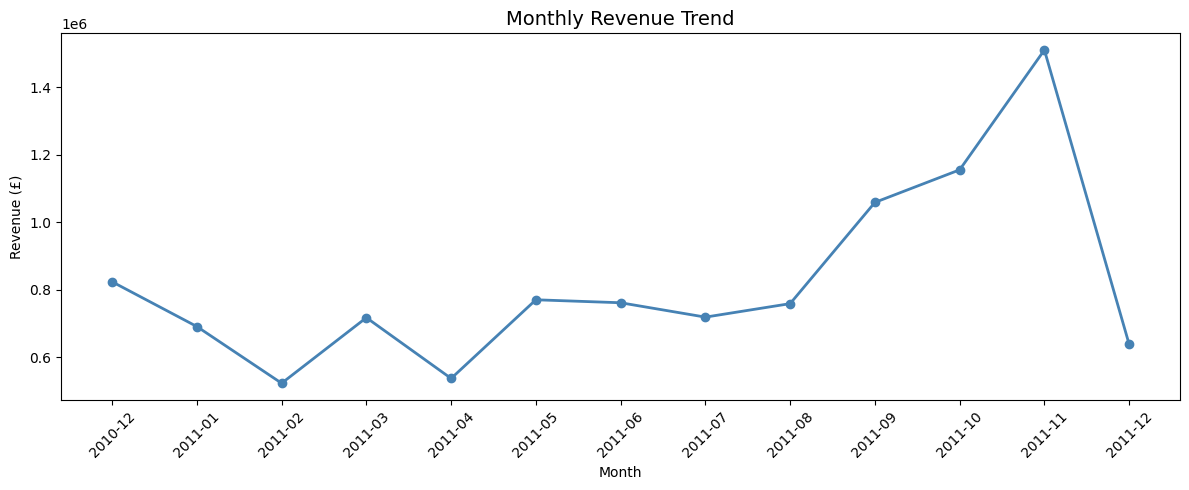

In [88]:
# Get monthly revenue data
monthly = sql("""
    SELECT 
        Year,
        Month,
        ROUND(SUM(Revenue), 2) as monthly_revenue
    FROM ecommerce
    GROUP BY Year, Month
    ORDER BY Year, Month
""")
# Create a proper date label
monthly['date'] = monthly ['Year'].astype(str)+ '-' + monthly['Month'].astype(str).str.zfill(2)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly['date'], monthly['monthly_revenue'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


November had highest revenue sale. christmas shopping season hit hard on November.

In [98]:
#top 10 best selling products
sql("""
    SELECT 
        Description,
        COUNT(*) as total_orders,
        SUM(Quantity) as total_units_sold,
        ROUND(SUM(Revenue), 2) as total_revenue
    FROM ecommerce
    WHERE Description NOT IN ('DOTCOM POSTAGE', 'POSTAGE', 'Manual')
    AND Description NOT LIKE '%POSTAGE%'
    GROUP BY Description
    ORDER BY total_revenue DESC
    LIMIT 10
""")


,Description,total_orders,total_units_sold,total_revenue
0,REGENCY CAKESTAND 3 TIER,2017,13879,174484.74
1,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
2,WHITE HANGING HEART T-LIGHT HOLDER,2323,37891,106292.77
3,PARTY BUNTING,1706,18295,99504.33
4,JUMBO BAG RED RETROSPOT,2112,48474,94340.05
5,MEDIUM CERAMIC TOP STORAGE JAR,250,78033,81700.92
6,RABBIT NIGHT LIGHT,1036,30788,66964.99
7,PAPER CHAIN KIT 50'S CHRISTMAS,1200,19355,64952.29
8,ASSORTED COLOUR BIRD ORNAMENT,1489,36461,59094.93
9,CHILLI LIGHTS,670,10306,54117.76


WHITE HANGING HEART T-LIGHT HOLDER is the consistent best seller, ordered by many customers and REGENCY CAKESTAND 3 TIER contributed highest total revenue

In [107]:
#customer analysis
sql("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT InvoiceNo) as total_orders,
        ROUND(SUM(Revenue), 2) as total_spent,
        ROUND(AVG(Revenue), 2) as avg_order_value,
        MIN(InvoiceDate) as first_order,
        MAX(InvoiceDate) as last_order
    FROM ecommerce
    WHERE CustomerID != 0
    GROUP BY CustomerID
    ORDER BY total_spent DESC
    LIMIT 10
""")

,CustomerID,total_orders,total_spent,avg_order_value,first_order,last_order
0,14646,73,280206.02,134.97,2010-12-20 10:09:00,2011-12-08 12:12:00
1,18102,60,259657.30,602.45,2010-12-07 16:42:00,2011-12-09 11:50:00
2,17450,46,194550.79,577.30,2010-12-07 09:23:00,2011-12-01 13:29:00
3,16446,2,168472.50,56157.50,2011-05-18 09:52:00,2011-12-09 09:15:00
4,14911,201,143825.06,25.34,2010-12-01 14:05:00,2011-12-08 15:54:00
5,12415,21,124914.53,174.95,2011-01-06 11:12:00,2011-11-15 14:22:00
6,14156,55,117379.63,83.84,2010-12-03 11:48:00,2011-11-30 10:54:00
7,17511,31,91062.38,94.56,2010-12-01 10:19:00,2011-12-07 10:12:00
8,16029,63,81024.84,334.81,2010-12-01 09:57:00,2011-11-01 10:27:00
9,12346,1,77183.60,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00


Customer 14646 shops regularly, spends big every time.-VIP customer.
Customer 16446 placed just 2 orders but spent £168k — almost certainly that bulk PAPER CRAFT order we found earlier! Same amount!
Customer 14911, is the loyal regular shop constantly but samll amounts.   


In [109]:
#The Pareto Principle
sql("""
    SELECT
        COUNT(DISTINCT CustomerID) as total_customers,
        ROUND(SUM(Revenue), 2) as total_revenue
    FROM ecommerce
    WHERE CustomerID != '0'
    AND CustomerID != 'Guest'
""")

sql("""
    WITH ranked AS (
        SELECT 
            CustomerID,
            SUM(Revenue) as total_spent,
            NTILE(5) OVER (ORDER BY SUM(Revenue) DESC) as quintile
        FROM ecommerce
        WHERE CustomerID != '0'
        AND CustomerID != 'Guest'
        GROUP BY CustomerID
    )
    SELECT
        quintile,
        COUNT(*) as customers,
        ROUND(SUM(total_spent), 2) as revenue,
        ROUND(SUM(total_spent) * 100.0 / SUM(SUM(total_spent)) OVER (), 1) as revenue_pct
    FROM ranked
    GROUP BY quintile
    ORDER BY quintile
""")

,quintile,customers,revenue,revenue_pct
0,1,868,6649437.46,74.6
1,2,868,1220211.09,13.7
2,3,868,597183.49,6.7
3,4,867,311486.22,3.5
4,5,867,133089.64,1.5


The top 20% generate 75% of revenue. means If this business lost their top 20% customers they'd lose 75% of their income overnight.

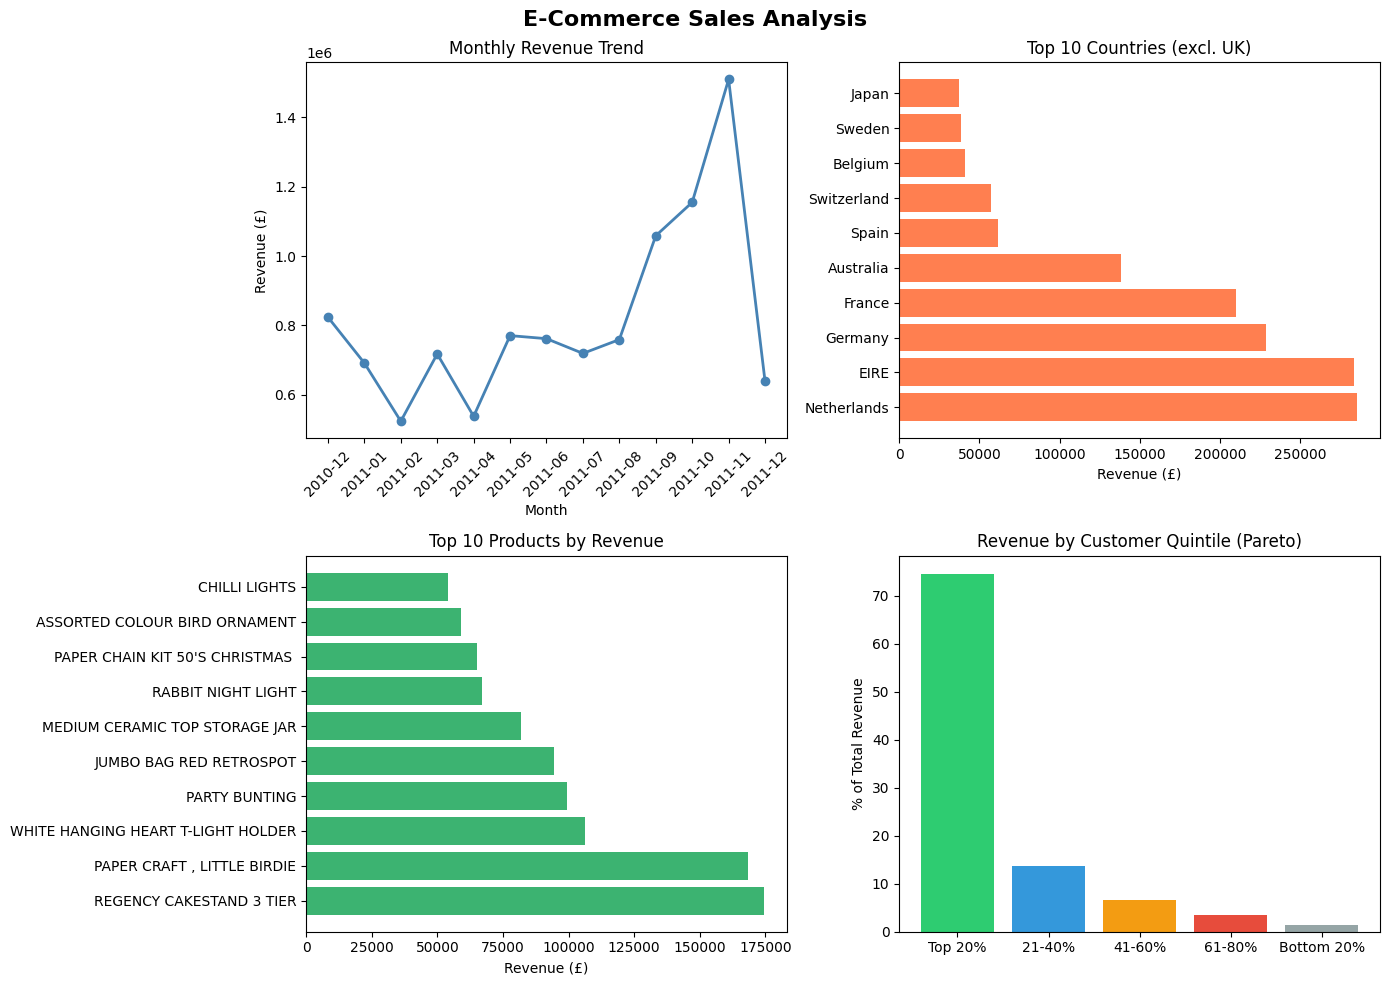

Dashboard saved!


In [110]:
#final visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-Commerce Sales Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Monthly Revenue
monthly = sql("""
    SELECT Year, Month, ROUND(SUM(Revenue), 2) as revenue
    FROM ecommerce
    GROUP BY Year, Month
    ORDER BY Year, Month
""")
monthly['date'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
axes[0,0].plot(monthly['date'], monthly['revenue'], marker='o', color='steelblue', linewidth=2)
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 — Top 10 Countries
countries = sql("""
    SELECT Country, ROUND(SUM(Revenue), 2) as revenue
    FROM ecommerce
    WHERE Country != 'United Kingdom'
    GROUP BY Country
    ORDER BY revenue DESC
    LIMIT 10
""")
axes[0,1].barh(countries['Country'], countries['revenue'], color='coral')
axes[0,1].set_title('Top 10 Countries (excl. UK)')
axes[0,1].set_xlabel('Revenue (£)')

# Chart 3 — Top 10 Products
products = sql("""
    SELECT Description, ROUND(SUM(Revenue), 2) as revenue
    FROM ecommerce
    WHERE Description NOT IN ('DOTCOM POSTAGE', 'POSTAGE', 'Manual')
    AND Description NOT LIKE '%POSTAGE%'
    GROUP BY Description
    ORDER BY revenue DESC
    LIMIT 10
""")
axes[1,0].barh(products['Description'], products['revenue'], color='mediumseagreen')
axes[1,0].set_title('Top 10 Products by Revenue')
axes[1,0].set_xlabel('Revenue (£)')

# Chart 4 — Pareto Chart
quintiles = sql("""
    WITH ranked AS (
        SELECT CustomerID, SUM(Revenue) as total_spent,
            NTILE(5) OVER (ORDER BY SUM(Revenue) DESC) as quintile
        FROM ecommerce
        WHERE CustomerID != '0' AND CustomerID != 'Guest'
        GROUP BY CustomerID
    )
    SELECT quintile,
        ROUND(SUM(total_spent) * 100.0 / SUM(SUM(total_spent)) OVER (), 1) as revenue_pct
    FROM ranked
    GROUP BY quintile
""")
axes[1,1].bar(['Top 20%', '21-40%', '41-60%', '61-80%', 'Bottom 20%'],
              quintiles['revenue_pct'], color=['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6'])
axes[1,1].set_title('Revenue by Customer Quintile (Pareto)')
axes[1,1].set_ylabel('% of Total Revenue')

plt.tight_layout()
plt.savefig('ecommerce_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")